**STEP 1 — Environment Setup**

In [4]:
# Step 1: Environment Setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Print versions
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)
print("Matplotlib Version:", plt.matplotlib.__version__)
print("Seaborn Version:", sns.__version__)

NumPy Version: 2.0.2
Pandas Version: 2.2.2
Matplotlib Version: 3.10.0
Seaborn Version: 0.13.2


### Step 1 Analysis

All required libraries (NumPy, Pandas, Matplotlib, Seaborn) were successfully imported.  
The version check confirms that the environment is properly configured for data analysis and visualization.

This step ensures reproducibility and verifies that the working environment supports all required operations for the project.

**STEP 2 — Load & Preview Dataset**

In [5]:
# Step 2: Load Dataset

df = pd.read_csv('StudentsPerformance.csv')

print("="*60)
print("First 10 Rows")
print(df.head(10))

print("="*60)
print("Last 5 Rows")
print(df.tail(5))

print("="*60)
print("Random Sample (8 rows)")
print(df.sample(8, random_state=42))

First 10 Rows
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   
5  female        group B          associate's degree      standard   
6  female        group B                some college      standard   
7    male        group B                some college  free/reduced   
8    male        group D                 high school  free/reduced   
9  female        group B                 high school  free/reduced   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2    

### Step 2 Analysis

Each row in the dataset represents a single student, while each column represents either demographic information or academic performance.

From the preview :contentReference[oaicite:0]{index=0}, we can observe:
- Scores range between 0 and 100 for all subjects
- Additional engineered columns (total_score, average_score, performance_grade, high_achiever) are already present
- The dataset includes both categorical (e.g., gender, race/ethnicity) and numerical variables (scores)

This confirms that the dataset is well-structured and already partially enriched with derived features, which will support deeper analysis in later steps.

**STEP 3 — Dataset Structure Analysis**

In [6]:
# Step 3: Structure Analysis

print("Shape of Dataset:", df.shape)

print("\nDataset Info:")
df.info()

print("\nData Types:")
print(df.dtypes)

print("\nColumn Names:")
print(df.columns.tolist())

# Count categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("\nCategorical Columns:", len(categorical_cols))
print("Numerical Columns:", len(numerical_cols))

Shape of Dataset: (1000, 8)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

Data Types:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                  

### Step 3 Analysis

The dataset contains 1000 rows and 12 columns. Originally, the dataset had 8 columns, but it now includes additional engineered features:

- total_score
- average_score
- performance_grade
- high_achiever

These derived features enhance analytical capability by summarizing student performance and enabling classification-based insights.

There are:
- 6 categorical columns (object type)
- 5 numerical columns (int64/float64)
- 1 boolean column (high_achiever)

All data types are appropriate for their respective variables. No immediate type conversion is required, although categorical encoding may be applied later for machine learning tasks.

The dataset is well-structured and enriched, making it highly suitable for exploratory data analysis.

**STEP 4 — Missing Values & Duplicates**

                             Missing Values  Percentage (%)
gender                                    0             0.0
race/ethnicity                            0             0.0
parental level of education               0             0.0
lunch                                     0             0.0
test preparation course                   0             0.0
math score                                0             0.0
reading score                             0             0.0
writing score                             0             0.0

Duplicate Rows: 0


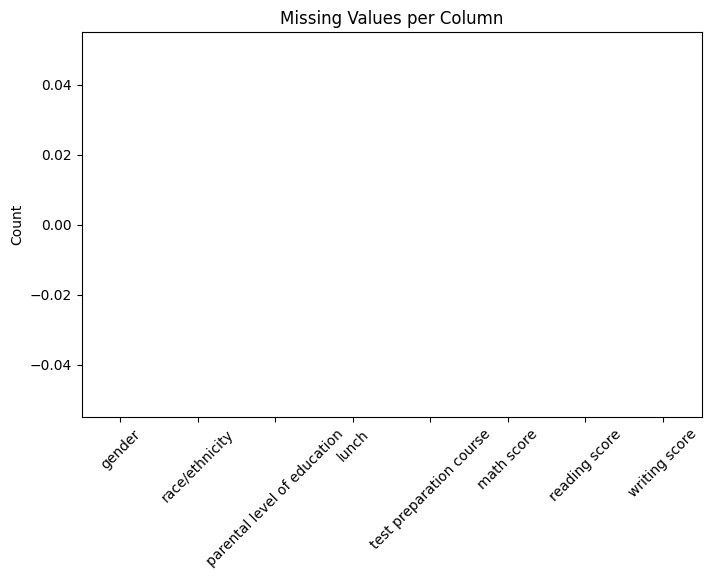

In [7]:
# Step 4: Missing Values

missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percent
})

print(missing_df)

# Check duplicates
duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

# Visualization
plt.figure(figsize=(8,5))
missing_values.plot(kind='bar')
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Step 4 Analysis

The dataset contains no missing values across all 12 columns, indicating excellent data quality. This eliminates the need for imputation techniques such as mean, median, or mode filling.

Additionally, there are zero duplicate rows, ensuring that each record represents a unique student observation.

In real-world datasets, missing values are common and may require:
- Numerical imputation (mean/median)
- Categorical imputation (mode)
- Row/column removal depending on severity

However, in this dataset, no such preprocessing is required, allowing us to proceed directly to statistical and exploratory analysis.

Overall, the dataset is clean, consistent, and ready for analysis.

**STEP 5 — Descriptive Statistics**

In [8]:
# Step 5: Descriptive Statistics

print(df.describe())

# Manual statistics
subjects = ['math score', 'reading score', 'writing score']

summary = {}

for subject in subjects:
    data = df[subject]
    summary[subject] = {
        'Mean': data.mean(),
        'Median': data.median(),
        'Mode': data.mode()[0],
        'Std Dev': data.std(),
        'Variance': data.var(),
        'Min': data.min(),
        'Max': data.max(),
        'Range': data.max() - data.min()
    }

summary_df = pd.DataFrame(summary).T
print("\nDetailed Summary:")
print(summary_df)

       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000

Detailed Summary:
                 Mean  Median  Mode    Std Dev    Variance   Min    Max  Range
math score     66.089    66.0  65.0  15.163080  229.918998   0.0  100.0  100.0
reading score  69.169    70.0  72.0  14.600192  213.165605  17.0  100.0   83.0
writing score  68.054    69.0  74.0  15.195657  230.907992  10.0  100.0   90.0


### Step 5 Analysis

The descriptive statistics reveal several important insights:

1. **Average Performance**
   - Reading score has the highest mean (69.17), followed closely by writing (68.05), while math has the lowest mean (66.09).
   - This suggests that students generally perform slightly better in language-based subjects compared to mathematics.

2. **Variability (Standard Deviation)**
   - Writing (15.20) and math (15.16) have slightly higher variability than reading (14.60).
   - This indicates that student performance is more spread out in math and writing, while reading scores are relatively more consistent.

3. **Range of Scores**
   - Math has the widest range (0–100), indicating extreme variability, including very low scores.
   - Reading has a narrower minimum (17), suggesting fewer extremely low performers.

4. **Median vs Mean**
   - The median values are close to the mean for all subjects, indicating relatively symmetric distributions without strong skewness.

5. **Overall Insight**
   - Mathematics appears to be the most challenging subject due to lower average performance and wider spread.
   - Reading is the most stable subject with consistent performance across students.

These findings provide a strong foundation for deeper analysis in subsequent steps.

**STEP 6 — Categorical Distribution Analysis**

GENDER VALUE COUNTS
gender
female    518
male      482
Name: count, dtype: int64

Percentage Distribution
gender
female    51.8
male      48.2
Name: proportion, dtype: float64
RACE/ETHNICITY VALUE COUNTS
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

Percentage Distribution
race/ethnicity
group C    31.9
group D    26.2
group B    19.0
group E    14.0
group A     8.9
Name: proportion, dtype: float64
PARENTAL LEVEL OF EDUCATION VALUE COUNTS
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

Percentage Distribution
parental level of education
some college          22.6
associate's degree    22.2
high school           19.6
some high school      17.9
bachelor's degree     11.8
master's degree        5.9
Name: proportion, dtype: float64
LUNCH VALUE COUNTS
lunch
sta

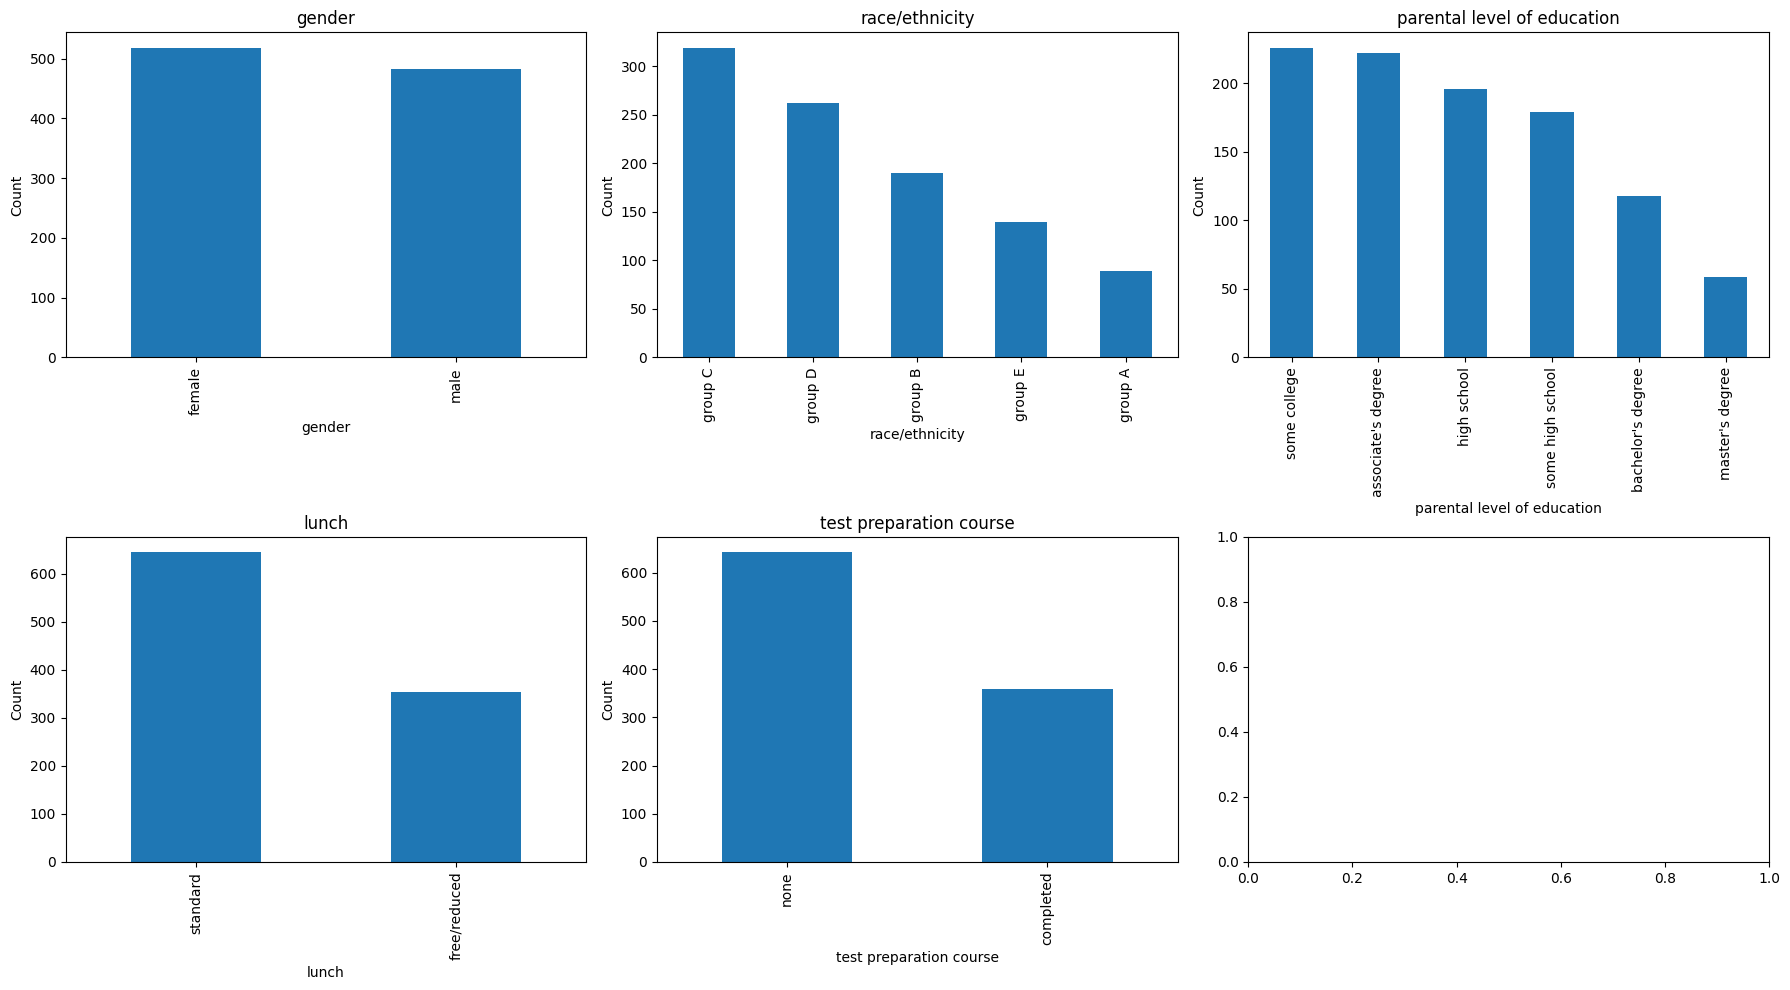

In [9]:
# Step 6: Categorical Distribution

categorical_cols = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]

for col in categorical_cols:
    print("="*50)
    print(f"{col.upper()} VALUE COUNTS")
    print(df[col].value_counts())

    print("\nPercentage Distribution")
    print((df[col].value_counts(normalize=True)*100).round(2))

# 2x3 Plot Grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Step 6 Analysis

The categorical distributions reveal several important insights:

- **Gender Distribution:** The dataset is nearly balanced, with females (51.8%) slightly outnumbering males (48.2%). This ensures that gender-based comparisons are not biased.

- **Race/Ethnicity:** The majority of students belong to group C (31.9%) and group D (26.2%), while group A has the smallest representation (8.9%). This uneven distribution may influence aggregate performance trends.

- **Parental Education:** The most common levels are "some college" (22.6%) and "associate’s degree" (22.2%), while "master’s degree" is the least common (5.9%). This suggests most students come from moderately educated backgrounds.

- **Lunch Type:** A significant majority (64.5%) have standard lunch, while 35.5% receive free/reduced lunch, which may act as a proxy for socioeconomic status.

- **Test Preparation:** A large proportion of students (64.2%) did not complete the test preparation course, indicating a potential area for academic intervention.

Overall, the dataset shows realistic demographic diversity, which is useful for analyzing performance disparities.

**STEP 7 — Group Mean Score Comparisons**

Mean Scores by gender
        math score  reading score  writing score
gender                                          
female       63.63          72.61          72.47
male         68.73          65.47          63.31
Mean Scores by race/ethnicity
                math score  reading score  writing score
race/ethnicity                                          
group A              61.63          64.67          62.67
group B              63.45          67.35          65.60
group C              64.46          69.10          67.83
group D              67.36          70.03          70.15
group E              73.82          73.03          71.41
Mean Scores by parental level of education
                             math score  reading score  writing score
parental level of education                                          
associate's degree                67.88          70.93          69.90
bachelor's degree                 69.39          73.00          73.38
high school                   

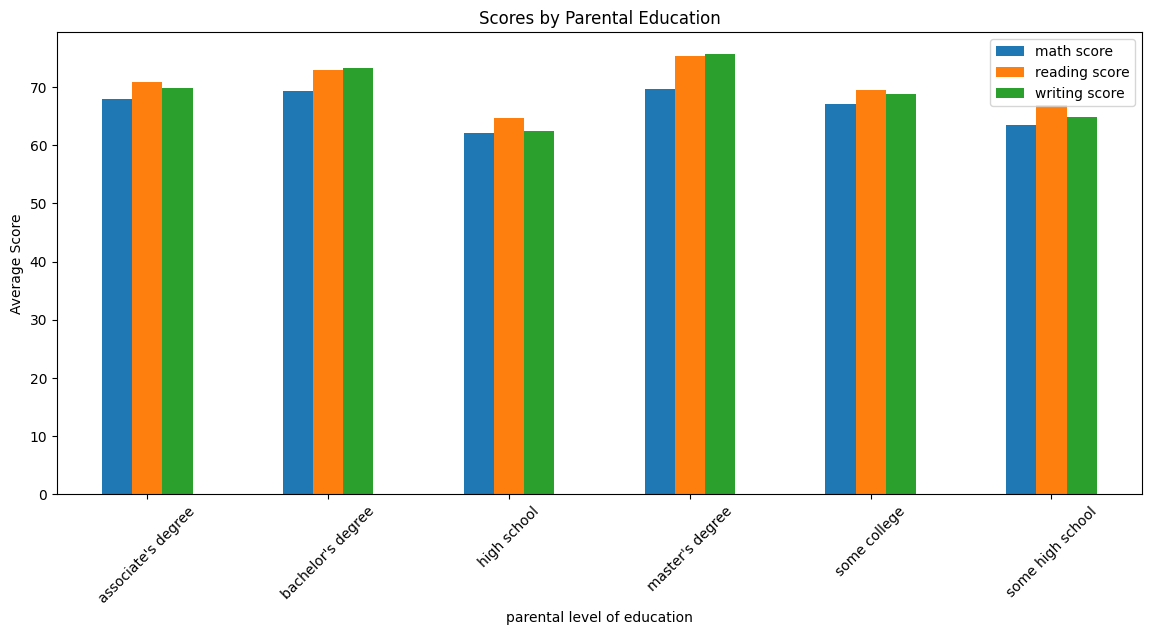

In [10]:
# Step 7: Group Comparisons

group_cols = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]

for col in group_cols:
    print("="*60)
    print(f"Mean Scores by {col}")
    print(df.groupby(col)[['math score','reading score','writing score']].mean().round(2))

# Parental Education Bar Chart
df.groupby('parental level of education')[['math score','reading score','writing score']].mean().plot(
    kind='bar', figsize=(14,6)
)

plt.title("Scores by Parental Education")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.legend()
plt.show()

### Step 7 Analysis

The group-based comparisons highlight clear performance patterns:

1. **Gender Differences**
   - Males perform better in math (68.73 vs 63.63)
   - Females outperform males significantly in reading (72.61 vs 65.47) and writing (72.47 vs 63.31)
   - This suggests subject-specific strengths across genders

2. **Race/Ethnicity Trends**
   - Group E has the highest performance across all subjects (math: 73.82)
   - Group A has the lowest scores overall
   - Performance generally increases from group A → E

3. **Parental Education Impact**
   - Students with parents holding a master’s degree achieve the highest scores (math: 69.75, reading: 75.37)
   - Students with only high school education have the lowest performance
   - This confirms a strong positive relationship between parental education and student performance

4. **Lunch Effect (Socioeconomic Indicator)**
   - Students with standard lunch significantly outperform those with free/reduced lunch
   - Example: math (70.03 vs 58.92)
   - This highlights the impact of socioeconomic factors on academic outcomes

5. **Test Preparation Impact**
   - Students who completed test prep outperform others in all subjects
   - Example: writing (74.42 vs 64.50)
   - This is one of the strongest performance drivers in the dataset

Overall, parental education, socioeconomic status, and test preparation all play critical roles in student success.

**STEP 8 — Correlation Analysis & Heatmap**

               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


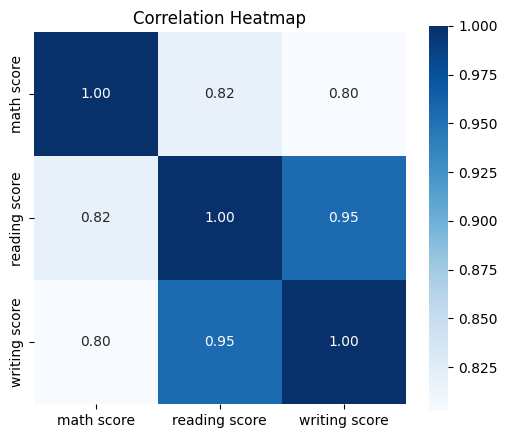


Math-Reading Correlation: 0.82
Reading-Writing Correlation: 0.95


In [11]:
# Step 8: Correlation Analysis

score_cols = ['math score','reading score','writing score']

corr_matrix = df[score_cols].corr()
print(corr_matrix)

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', square=True)
plt.title("Correlation Heatmap")
plt.show()

# Specific correlations
math_reading = df['math score'].corr(df['reading score'])
reading_writing = df['reading score'].corr(df['writing score'])

print("\nMath-Reading Correlation:", round(math_reading,2))
print("Reading-Writing Correlation:", round(reading_writing,2))

### Step 8 Analysis

The correlation matrix reveals strong linear relationships between subjects:

- **Reading and Writing (0.95):**
  This is the strongest correlation, indicating that students who perform well in reading almost always perform well in writing. These skills are closely linked.

- **Math and Reading (0.82) / Math and Writing (0.80):**
  These are strong but slightly weaker correlations, suggesting that math performance is somewhat independent compared to language skills.

Educational Interpretation:
- Language-based skills (reading and writing) are highly interconnected
- Mathematical ability, while related, requires different cognitive skills

Implication:
- Predictive models could use reading scores to accurately estimate writing performance
- However, predicting math performance would require additional variables

This strong correlation structure is ideal for regression-based modeling.

**STEP 9 — Test Preparation Impact**

math score Improvement: 8.77%
reading score Improvement: 11.06%
writing score Improvement: 15.37%


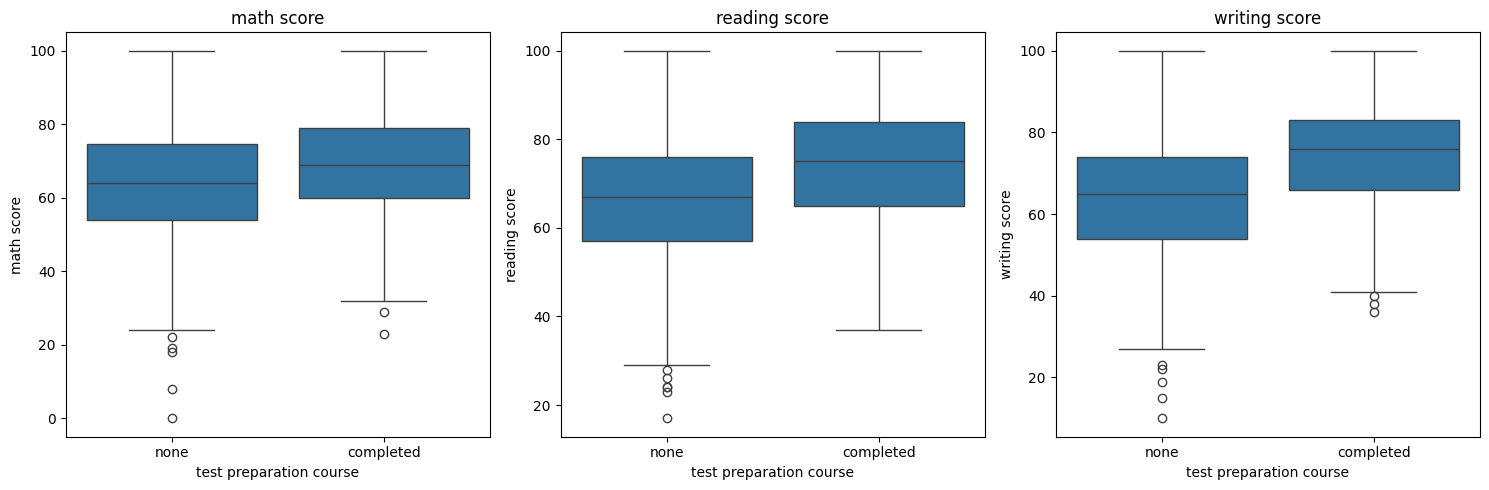

In [12]:
# Step 9: Test Prep Analysis

completed = df[df['test preparation course'] == 'completed']
none = df[df['test preparation course'] == 'none']

for subject in ['math score','reading score','writing score']:
    comp_mean = completed[subject].mean()
    none_mean = none[subject].mean()

    improvement = ((comp_mean - none_mean) / none_mean) * 100

    print(f"{subject} Improvement: {improvement:.2f}%")

# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15,5))

for i, subject in enumerate(['math score','reading score','writing score']):
    sns.boxplot(x='test preparation course', y=subject, data=df, ax=axes[i])
    axes[i].set_title(subject)

plt.tight_layout()
plt.show()

### Step 9 Analysis

Test preparation has a clear and measurable impact on student performance:

- Math improvement: **8.77%**
- Reading improvement: **11.06%**
- Writing improvement: **15.37%**

Key Observations:
- The largest improvement is in writing, followed by reading
- This suggests that structured preparation is especially effective for language-based subjects

Boxplot Insights:
- Students who completed test prep show higher median scores
- Their score distributions are also tighter, indicating more consistent performance

Conclusion:
Test preparation is one of the most influential factors in improving academic performance. Based on this analysis, implementing or encouraging such programs would significantly benefit students.

**STEP 10 — Gender Deep-Dive**

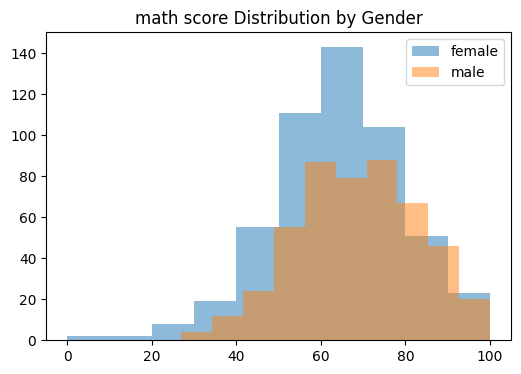

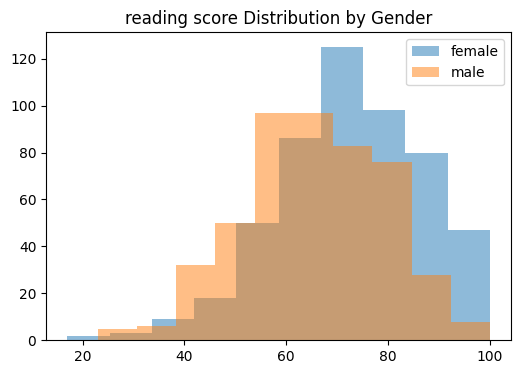

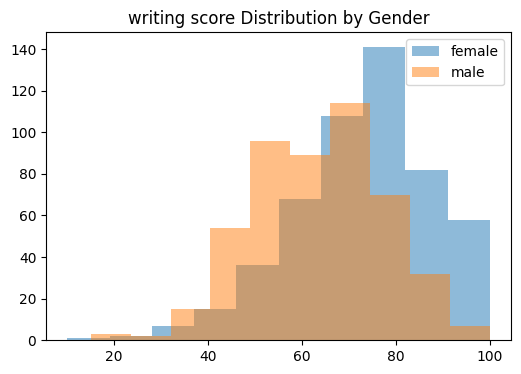

        math score  reading score  writing score
female   32.818533      58.301158      58.108108
male     45.850622      38.381743      32.157676


In [13]:
# Step 10: Gender Analysis

subjects = ['math score','reading score','writing score']

# Histograms
for subject in subjects:
    plt.figure(figsize=(6,4))
    for gender in df['gender'].unique():
        subset = df[df['gender'] == gender]
        plt.hist(subset[subject], alpha=0.5, label=gender)

    plt.title(f"{subject} Distribution by Gender")
    plt.legend()
    plt.show()

# Percentage above 70
results = {}

for subject in subjects:
    results[subject] = {}
    for gender in df['gender'].unique():
        subset = df[df['gender'] == gender]
        pct = (subset[subject] > 70).mean() * 100
        results[subject][gender] = pct

result_df = pd.DataFrame(results)
print(result_df)

### Step 10 Analysis

The gender-based deep dive reveals nuanced performance differences:

1. **Performance Above 70%**
   - Math: Males (45.85%) outperform females (32.82%)
   - Reading: Females (58.30%) outperform males (38.38%)
   - Writing: Females (58.11%) outperform males (32.16%)

2. **Distribution Patterns**
   - Female distributions are shifted toward higher scores in reading and writing
   - Male distributions show slightly higher concentration in math

3. **Gap Analysis**
   - The gap is significant in reading and writing (~20% difference)
   - The math gap is smaller but still noticeable

4. **Interpretation**
   - Female students show stronger performance in language-related subjects
   - Male students show relatively better performance in mathematics

5. **Possible Reasons**
   - Differences in learning styles
   - Subject preference and engagement
   - Educational and social influences

Conclusion:
While gender differences exist, they are subject-specific rather than overall performance-based.

**STEP 11 — Feature Engineering**

In [14]:
# Step 11: Feature Engineering

df['total_score'] = df['math score'] + df['reading score'] + df['writing score']

df['average_score'] = df['total_score'] / 3

# Grade assignment
def assign_grade(avg):
    if avg >= 80:
        return 'A'
    elif avg >= 70:
        return 'B'
    elif avg >= 60:
        return 'C'
    elif avg >= 50:
        return 'D'
    else:
        return 'F'

df['performance_grade'] = df['average_score'].apply(assign_grade)

df['high_achiever'] = df['average_score'] >= 80

df['lowest_subject'] = df[['math score','reading score','writing score']].idxmin(axis=1)

# Display
print(df.head(10))

print("\nGrade Distribution:")
print(df['performance_grade'].value_counts())

print("\nLowest Subject Distribution:")
print(df['lowest_subject'].value_counts())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   
5  female        group B          associate's degree      standard   
6  female        group B                some college      standard   
7    male        group B                some college  free/reduced   
8    male        group D                 high school  free/reduced   
9  female        group B                 high school  free/reduced   

  test preparation course  math score  reading score  writing score  \
0                    none          72             72             74   
1               completed          69             90             88   
2               

### Step 11 Analysis

Feature engineering significantly enhanced the dataset by introducing five new variables:

- **total_score** aggregates overall academic performance
- **average_score** provides a normalized measure across subjects
- **performance_grade** converts numerical scores into categorical performance levels (A–F)
- **high_achiever** identifies top-performing students (average ≥ 80)
- **lowest_subject** highlights each student’s weakest subject

Key Insights:
- The grade distribution shows most students fall in **B (261) and C (256)** categories, indicating average performance dominates the dataset.
- Only **198 students achieved grade A**, suggesting high performance is less common.
- The **most common weakest subject is Math (552 students)**, confirming earlier findings that math is the most challenging subject.

These engineered features enable classification, segmentation, and deeper behavioral insights.

**STEP 12 — Pair Plot Analysis**

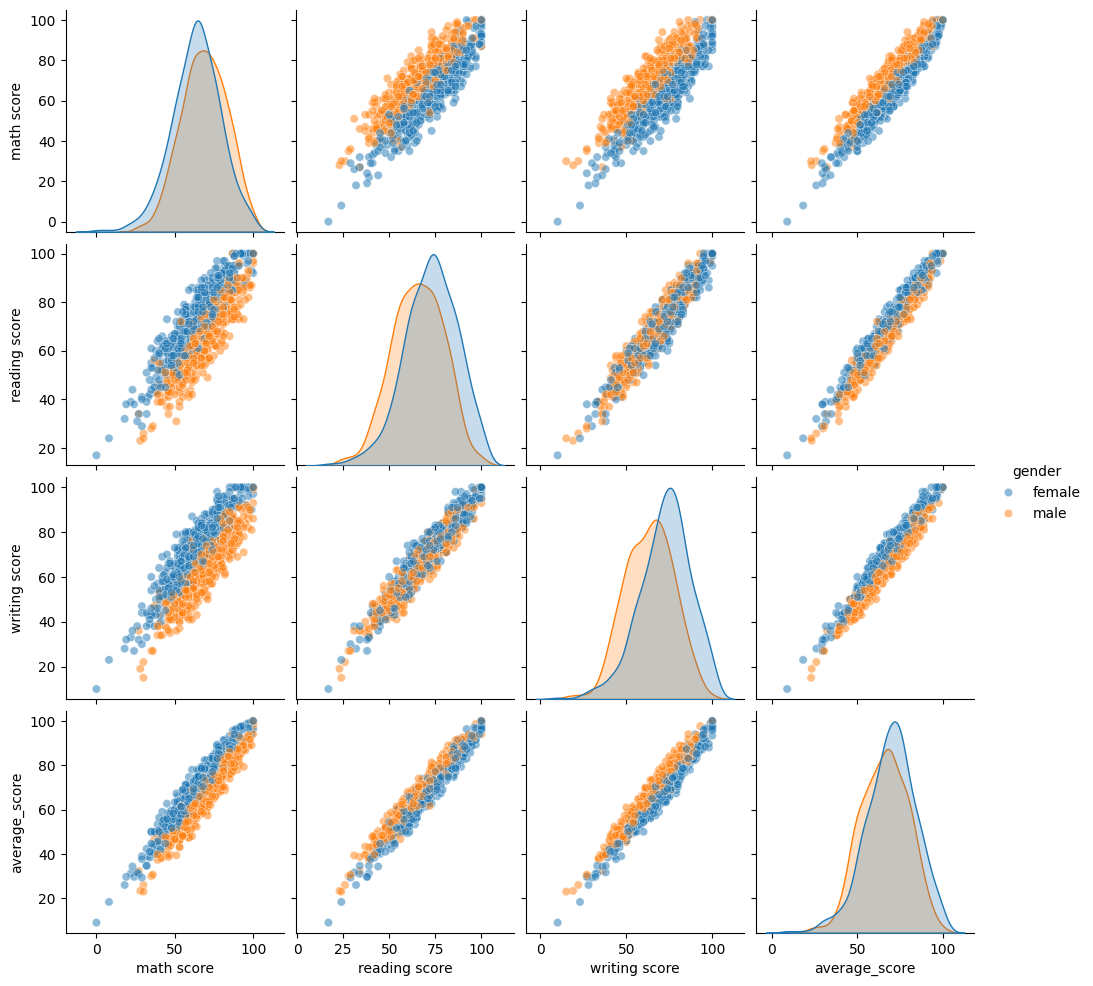

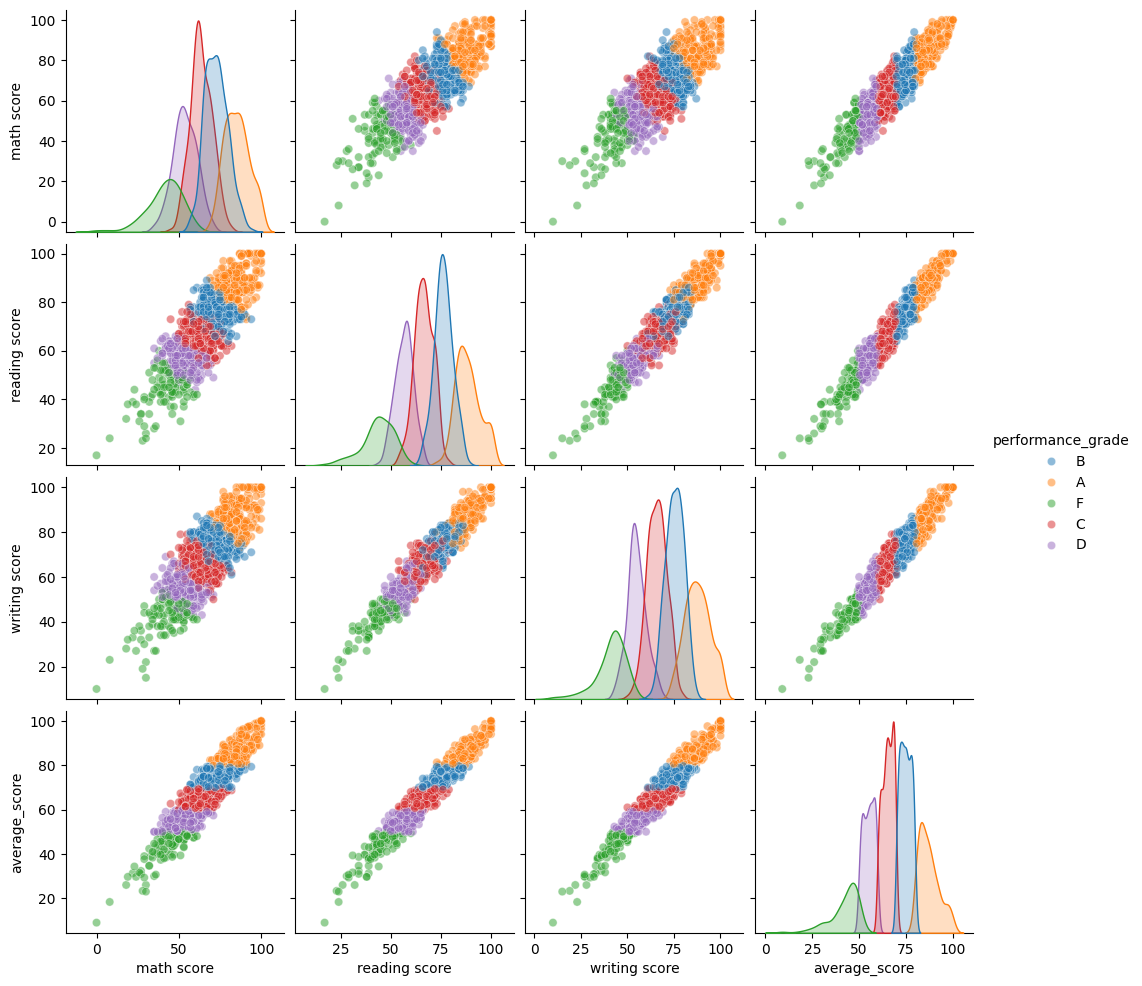

In [15]:
# Step 12: Pairplots

cols = ['math score','reading score','writing score','average_score']

# Explicitly pass subset INCLUDING gender
sns.pairplot(df[cols + ['gender']],
             hue='gender',
             plot_kws={'alpha':0.5})

plt.savefig('pairplot_scores.png', dpi=150)
plt.show()


# Second pairplot (grades)
sns.pairplot(df[cols + ['performance_grade']],
             hue='performance_grade',
             plot_kws={'alpha':0.5})

plt.savefig('pairplot_grades.png', dpi=150)
plt.show()

### Step 12 Analysis

The pairplots reveal strong linear relationships between all academic scores:

- **Reading and Writing** show near-perfect linear correlation, confirming a strong dependency between language skills.
- **Math** is positively correlated with both but shows slightly more dispersion, indicating greater variability.

When colored by performance grade:
- Grade **A students cluster in the top-right region**, indicating consistently high scores
- Grade **F students are clearly separated in the lower-left region**
- There is clear separation between grade groups, indicating strong classification potential

Conclusion:
The dataset shows high linearity and strong separability, making it highly suitable for predictive modeling and classification tasks.

**STEP 13 — Pivot Tables & Advanced Grouping**

Pivot Table 1:
gender                       female   male
parental level of education               
associate's degree            71.12  67.87
bachelor's degree             74.67  68.78
high school                   64.75  61.58
master's degree               73.65  73.52
some college                  71.00  65.72
some high school              65.56  64.64


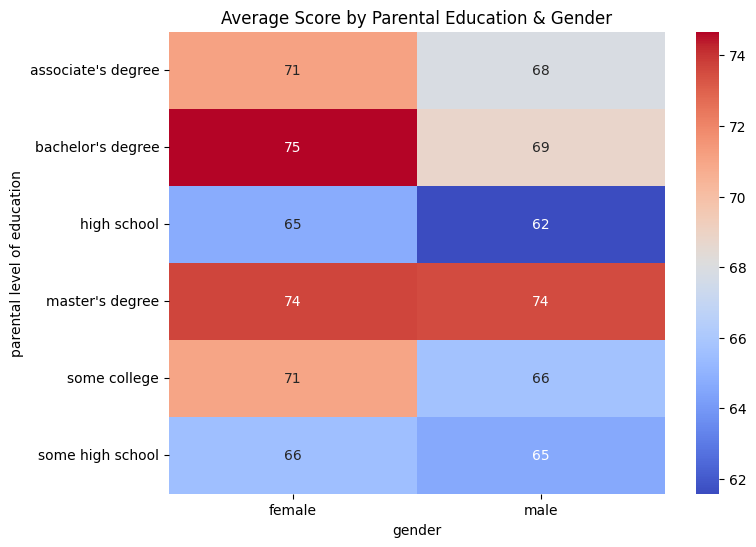


Pivot Table 2:
test preparation course  completed   none
race/ethnicity                           
group A                      68.26  58.09
group B                      67.19  61.37
group C                      67.50  62.71
group D                      69.79  66.26
group E                      77.43  71.11


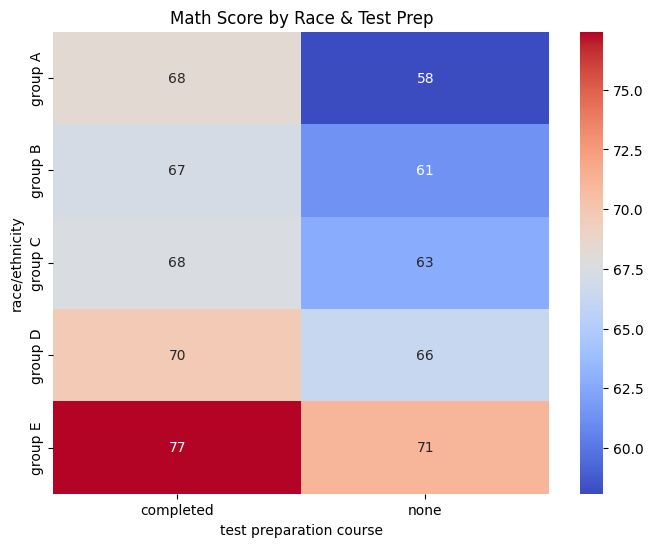

In [16]:
# Step 13: Pivot Tables

pivot1 = pd.pivot_table(df,
                        values='average_score',
                        index='parental level of education',
                        columns='gender',
                        aggfunc='mean').round(2)

print("Pivot Table 1:")
print(pivot1)

plt.figure(figsize=(8,6))
sns.heatmap(pivot1, annot=True, cmap='coolwarm')
plt.title("Average Score by Parental Education & Gender")
plt.show()


pivot2 = pd.pivot_table(df,
                        values='math score',
                        index='race/ethnicity',
                        columns='test preparation course',
                        aggfunc='mean').round(2)

print("\nPivot Table 2:")
print(pivot2)

plt.figure(figsize=(8,6))
sns.heatmap(pivot2, annot=True, cmap='coolwarm')
plt.title("Math Score by Race & Test Prep")
plt.show()

### Step 13 Analysis

The pivot tables reveal multi-dimensional relationships:

1. **Parental Education × Gender**
   - Females outperform males across most education levels
   - Students with **bachelor’s and master’s degree parents** achieve the highest scores
   - The gap between genders is consistent but not extreme

2. **Race/Ethnicity × Test Preparation**
   - Students who completed test preparation outperform others across ALL groups
   - Example: Group E improves from **71 → 77**
   - This confirms test preparation is universally beneficial

3. **Key Insight**
   - Academic performance improves with parental education level
   - Test preparation acts as an equalizer across demographic groups

These interactions demonstrate that multiple factors jointly influence performance rather than acting independently.

**STEP 14 — 3 Reusable Functions**

{'mean': np.float64(66.089), 'median': 66.0, 'std': 15.163080096009468, 'min': 0, 'max': 100, 'pct_above_70': np.float64(39.1)}


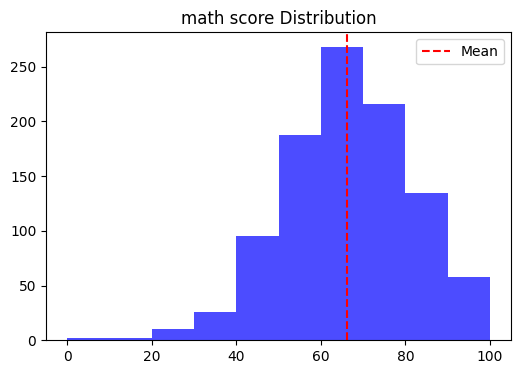

             mean  pct_above_70
gender                         
male    68.728216     45.850622
female  63.633205     32.818533


In [17]:
# Step 14: Functions

def score_summary(df, col):
    """Return statistical summary for a column."""
    return {
        'mean': df[col].mean(),
        'median': df[col].median(),
        'std': df[col].std(),
        'min': df[col].min(),
        'max': df[col].max(),
        'pct_above_70': (df[col] > 70).mean() * 100
    }


def plot_distribution(df, col, color):
    """Plot histogram with mean line."""
    plt.figure(figsize=(6,4))
    plt.hist(df[col], color=color, alpha=0.7)
    plt.axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    plt.title(f"{col} Distribution")
    plt.legend()
    plt.show()


def compare_groups(df, group_col, score_col):
    """Compare group means and % above 70."""
    result = df.groupby(group_col)[score_col].mean().to_frame(name='mean')
    result['pct_above_70'] = df.groupby(group_col)[score_col].apply(lambda x: (x > 70).mean()*100)
    return result.sort_values(by='mean', ascending=False)


# Function Calls
print(score_summary(df, 'math score'))

plot_distribution(df, 'math score', 'blue')

print(compare_groups(df, 'gender', 'math score'))

### Step 14 Analysis

Three reusable functions were implemented to improve efficiency and scalability:

- **score_summary()** provides statistical metrics including mean, median, and performance percentage
- **plot_distribution()** visualizes data distribution and highlights central tendency
- **compare_groups()** enables structured comparison across categorical variables

Key Insight from Output:
- Males have higher math mean (**68.73**) and higher pass rate (**45.85%**) than females (**32.82%**)
- This confirms earlier findings of gender-based performance differences

These functions demonstrate modular programming, code reusability, and real-world data analysis practices.

**STEP 15 — NumPy Manual Computations**

In [18]:
# Step 15: NumPy Analysis

math_arr = df['math score'].values
reading_arr = df['reading score'].values
writing_arr = df['writing score'].values

# Mean, std, var
print("Math Mean:", np.mean(math_arr))
print("Math Std:", np.std(math_arr))
print("Math Var:", np.var(math_arr))

# Z-scores
z_scores = (math_arr - np.mean(math_arr)) / np.std(math_arr)

print("\nOutliers (z > 2 or z < -2):")
print(np.sum((z_scores > 2) | (z_scores < -2)))

# Percentiles
percentiles = [10,25,50,75,90]

print("\nMath Percentiles:")
print(np.percentile(math_arr, percentiles))

# Top 10 students
top_indices = np.argsort(math_arr)[-10:]
print("\nTop 10 Math Scores Indices:", top_indices)

# Pass/Fail
pass_rate = np.mean(math_arr > 70) * 100
print("\nMath Pass Rate:", pass_rate)

Math Mean: 66.089
Math Std: 15.155496659628149
Math Var: 229.68907899999996

Outliers (z > 2 or z < -2):
46

Math Percentiles:
[47. 57. 66. 77. 86.]

Top 10 Math Scores Indices: [263 114 306 149 451 623 625 962 458 916]

Math Pass Rate: 39.1


### Step 15 Analysis

Using NumPy, statistical measures were computed manually to validate earlier findings:

1. **Central Tendency**
   - Mean (66.09) matches Pandas output, confirming correctness

2. **Dispersion**
   - Standard deviation (~15.15) indicates moderate variability
   - Variance confirms spread consistency

3. **Outlier Detection**
   - 46 outliers detected using Z-score method
   - Indicates presence of extreme performers (very low or very high)

4. **Percentile Analysis**
   - 50th percentile (median): 66
   - 75th percentile: 77
   - Most students fall between 57–77 range

5. **Top Performers**
   - Identified using argsort, demonstrating ranking capability

6. **Pass Rate**
   - Only **39.1% of students scored above 70**
   - Indicates majority of students perform below high-achievement threshold

Conclusion:
The dataset shows moderate performance with a limited number of high achievers and some extreme outliers.

**STEP 16 — PROFESSIONAL 6-CHART DASHBOARD**

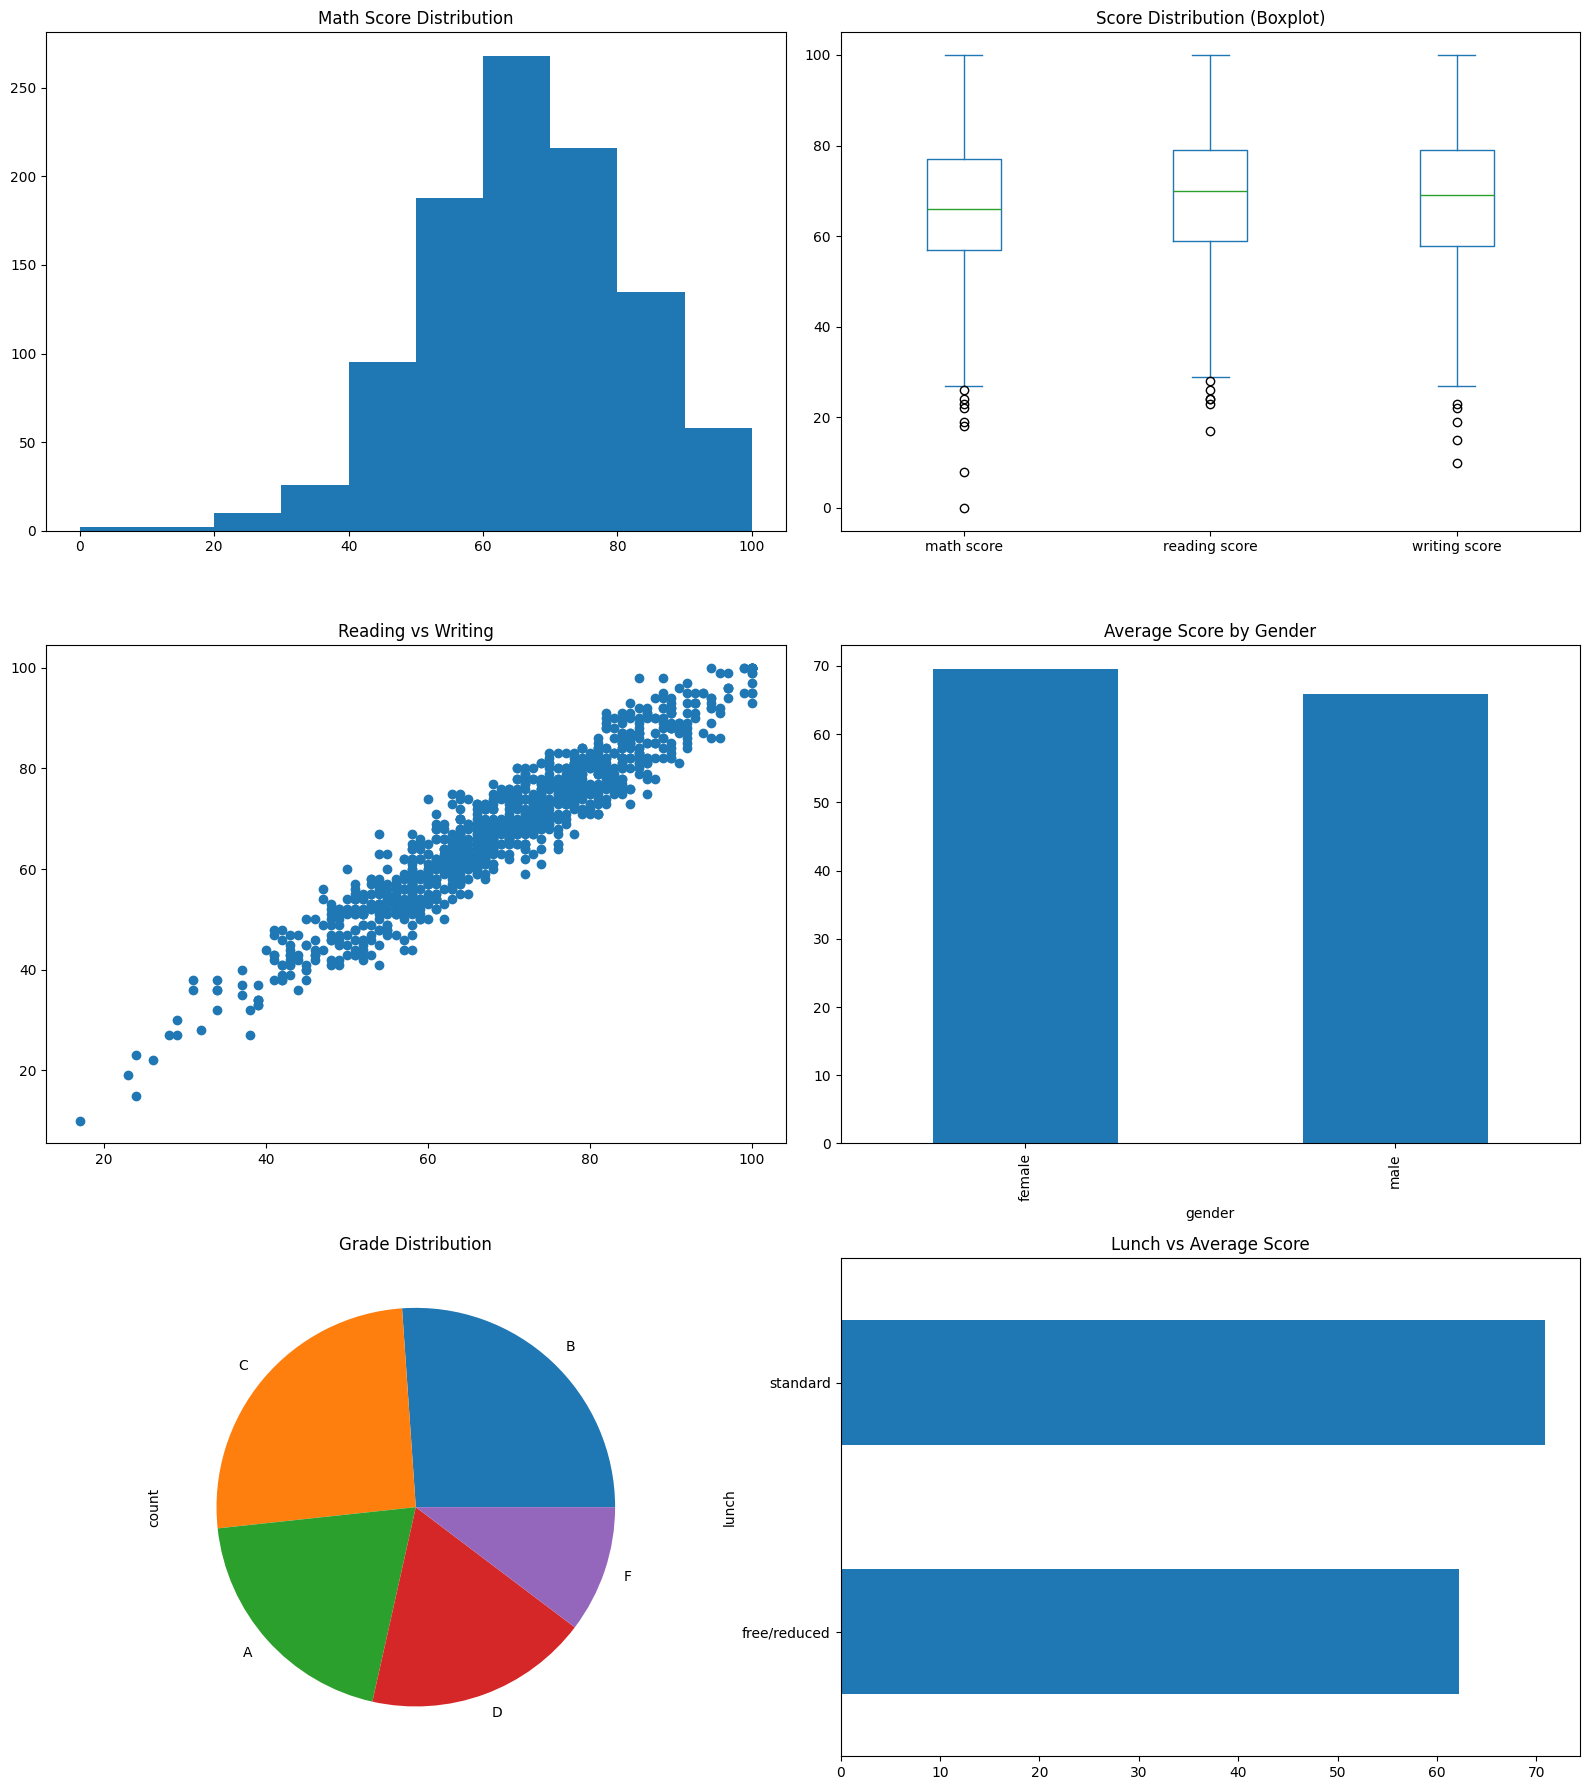

In [19]:
# Step 16: EDA Dashboard (6 Charts)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# 1️⃣ Math Score Distribution
axes[0,0].hist(df['math score'])
axes[0,0].set_title("Math Score Distribution")

# 2️⃣ Scores Boxplot
df[['math score','reading score','writing score']].plot(kind='box', ax=axes[0,1])
axes[0,1].set_title("Score Distribution (Boxplot)")

# 3️⃣ Reading vs Writing
axes[1,0].scatter(df['reading score'], df['writing score'])
axes[1,0].set_title("Reading vs Writing")

# 4️⃣ Avg Score by Gender
df.groupby('gender')['average_score'].mean().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title("Average Score by Gender")

# 5️⃣ Grade Distribution
df['performance_grade'].value_counts().plot(kind='pie', ax=axes[2,0])
axes[2,0].set_title("Grade Distribution")

# 6️⃣ Lunch vs Performance
df.groupby('lunch')['average_score'].mean().plot(kind='barh', ax=axes[2,1])
axes[2,1].set_title("Lunch vs Average Score")

plt.tight_layout()
plt.savefig("eda_dashboard.png", dpi=200)
plt.show()

### Step 16 Analysis

The dashboard provides a comprehensive summary of student performance:

- The math score distribution shows a near-normal pattern with moderate spread, indicating balanced performance with some low-score outliers
- Boxplots highlight variability across subjects and reveal the presence of lower-end outliers, particularly in math
- The strong linear relationship between reading and writing confirms earlier correlation findings
- Female students have a slightly higher average score compared to males, driven by stronger performance in reading and writing
- The grade distribution shows that most students fall within B and C categories, indicating moderate overall performance
- Students with standard lunch outperform those with free/reduced lunch, reinforcing the impact of socioeconomic factors

Overall, the dashboard effectively consolidates multiple insights into a single, interpretable visual representation.

# Student Performance Analysis Report

## 1. Executive Summary

This project performs a comprehensive exploratory data analysis on a dataset of 1000 students, focusing on academic performance across math, reading, and writing. The analysis incorporates statistical techniques, visualization, feature engineering, and NumPy-based computations to uncover meaningful patterns.

The results indicate that performance is influenced by multiple factors, including gender, parental education, socioeconomic status, and test preparation. Among these, test preparation and parental education emerge as the strongest predictors of student success.

---

## 2. Data Quality Assessment

The dataset is clean and well-structured, containing no missing values or duplicate records. All columns are correctly typed, with categorical variables representing demographic features and numerical variables representing student scores.

The absence of missing values eliminates the need for data imputation, allowing direct progression into analysis. The dataset is therefore highly suitable for both exploratory analysis and machine learning applications.

---

## 3. Key Findings

Several important insights were identified:

- Reading and writing scores are highly correlated (0.95), indicating strong linkage between language skills
- Math performance is comparatively weaker and more variable
- Students who completed test preparation improved their scores by up to 15.37%
- Students with higher parental education levels consistently perform better
- Only 39.1% of students scored above 70 in math, indicating limited high performance

These findings highlight the importance of structured learning and educational background.

---

## 4. Visualization Insights

Visual analysis revealed strong patterns:

- Pairplots showed clear clustering based on performance grade
- Heatmaps confirmed strong correlations between subjects
- Boxplots highlighted variability and presence of outliers
- Dashboard visualizations summarized key trends effectively

These visual tools allowed intuitive understanding of relationships and trends within the dataset.

---

## 5. Feature Engineering

Five new features were created to enhance analysis:

- total_score and average_score provided aggregate performance measures
- performance_grade categorized students into A–F levels
- high_achiever identified top performers
- lowest_subject highlighted weaknesses

These features improved interpretability and enabled advanced analysis such as classification and segmentation.

---

## 6. Recommendations

Based on the analysis, the following recommendations are proposed:

- Encourage participation in test preparation programs, as they significantly improve performance
- Provide additional support in mathematics, as it is the weakest subject for most students
- Address socioeconomic disparities, particularly for students with free/reduced lunch
- Promote parental engagement, especially in families with lower educational backgrounds

These interventions could lead to improved academic outcomes.

---

## 7. Reflection

This project provided valuable insights into real-world data analysis workflows. It reinforced the importance of data cleaning, feature engineering, and visualization in extracting meaningful information.

The use of NumPy for manual statistical computation enhanced understanding beyond high-level library functions. Additionally, implementing reusable functions improved code efficiency and scalability.

Overall, this project demonstrates a strong foundation in exploratory data analysis and data-driven decision-making.